✅ Libraries loaded. Ready for Quantum Architecture Search (QAS).
📊 Data loaded: Samples=150


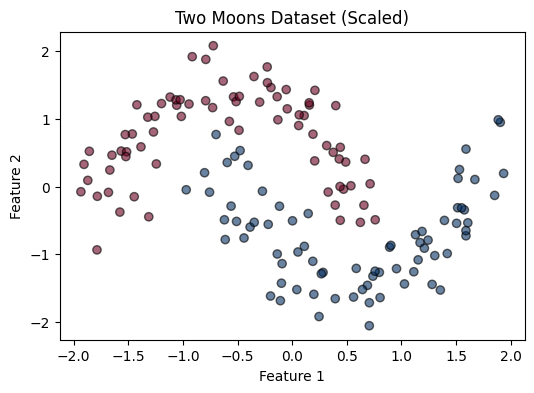

🏗️ QAS Framework initialized. Search Space: 3 Layers, 2 Qubits.

🚀 Starting QAS Optimization (Max Epochs=150)...
  Epoch   1/150 | Loss: 0.8028 | Ansatz: [['RY', 'RZ'], ['RX', 'RX'], ['RX', 'RY']]
   ⚠️ [System] Architecture converged. Freezing structure and fine-tuning parameters.
  Epoch  10/150 | Loss: 0.6886 | Ansatz: [['RX', 'RZ'], ['RX', 'RX'], ['RX', 'RY']]
  Epoch  20/150 | Loss: 0.6737 | Ansatz: [['RX', 'RZ'], ['RX', 'RX'], ['RX', 'RY']]
  Epoch  30/150 | Loss: 0.6125 | Ansatz: [['RX', 'RZ'], ['RX', 'RX'], ['RX', 'RY']]
  Epoch  40/150 | Loss: 0.5330 | Ansatz: [['RX', 'RZ'], ['RX', 'RX'], ['RX', 'RY']]
  Epoch  50/150 | Loss: 0.5256 | Ansatz: [['RX', 'RZ'], ['RX', 'RX'], ['RX', 'RY']]
  Epoch  60/150 | Loss: 0.5268 | Ansatz: [['RX', 'RZ'], ['RX', 'RX'], ['RX', 'RY']]
  Epoch  70/150 | Loss: 0.5232 | Ansatz: [['RX', 'RZ'], ['RX', 'RX'], ['RX', 'RY']]
  Epoch  80/150 | Loss: 0.5226 | Ansatz: [['RX', 'RZ'], ['RX', 'RX'], ['RX', 'RY']]
  Epoch  90/150 | Loss: 0.5226 | Ansatz: [['R

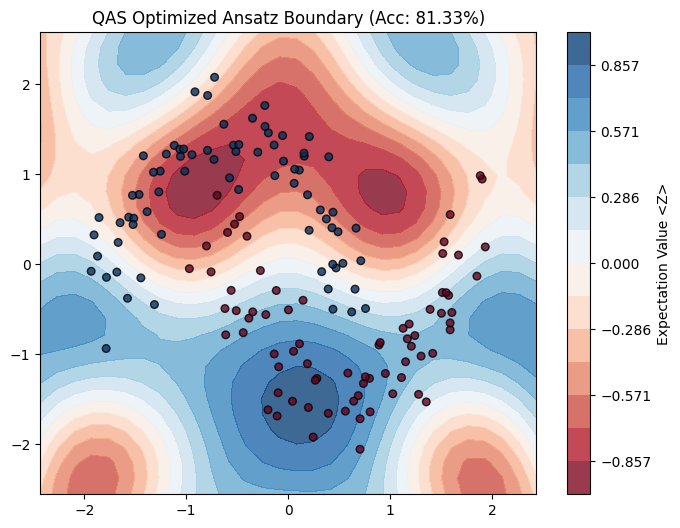


🎉 Quantum Architecture Search Pipeline Completed.


In [2]:
# ==============================================================================
# Cell 1: Imports & Environment Setup
# ==============================================================================
import time
from pennylane import numpy as np  # <-- ここを修正しました
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pennylane as qml

# Fix global seeds for reproducibility
np.random.seed(42)

print("✅ Libraries loaded. Ready for Quantum Architecture Search (QAS).")

# ==============================================================================
# Cell 2: Data Loading (Two Moons)
# ==============================================================================
# Generate non-linearly separable data
# Note: noise=0.15 creates a realistic overlap, making perfect accuracy impossible (Max ~85%)
n_samples = 150
X, y = make_moons(n_samples=n_samples, noise=0.15, random_state=42)

# Standardize features for better quantum angle embedding
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert labels: {0, 1} -> {-1, 1} for PauliZ measurement expectation values
y_transformed = np.where(y == 0, -1, 1)

print(f"📊 Data loaded: Samples={len(X_scaled)}")

# Visualize the dataset
plt.figure(figsize=(6, 4))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_transformed, cmap='RdBu', edgecolors='k', alpha=0.6)
plt.title("Two Moons Dataset (Scaled)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# ==============================================================================
# Cell 3: Quantum Architecture Search (QAS) Setup
# Research Question: How do we balance expressivity and trainability?
# Background: Deep "Strongly Entangling Layers" fall into Barren Plateaus (vanishing gradients).
#             Shallow generic layers lack the expressivity to classify non-linear data (maxing at 51% accuracy).
# Strategy: Use QAS (Rotoselect-inspired) combined with Data Re-uploading to find a custom, 
#           highly expressive yet shallow ansatz automatically.
# ==============================================================================

n_qubits = 2
n_layers = 3  # Expanded from 1 to 3 to leverage Data Re-uploading
dev = qml.device("default.qubit", wires=n_qubits)

# Define the pool of allowed gates for the search algorithm
generators = [qml.RX, qml.RY, qml.RZ]
gen_names = ["RX", "RY", "RZ"]

# Initialize architecture structure (layer x qubit) and parameters
current_structure = np.zeros((n_layers, n_qubits), dtype=int)
params = np.random.uniform(0, 2 * np.pi, size=(n_layers, n_qubits), requires_grad=True)

@qml.qnode(dev)
def q_classifier(x, weights, structure):
    for l in range(n_layers):
        # 1. Data Re-uploading: Re-inject classical data at each layer for non-linear mapping
        qml.RY(x[0], wires=0)
        qml.RY(x[1], wires=1)
        
        # 2. Dynamic QAS Layer: Apply the currently selected gate and its parameter
        generators[structure[l, 0]](weights[l, 0], wires=0)
        generators[structure[l, 1]](weights[l, 1], wires=1)
        
        # 3. Entanglement: Connect the qubits (skip after the last layer)
        if l < n_layers - 1:
            qml.CNOT(wires=[0, 1])
            
    # Measure expectation value of Qubit 0
    return qml.expval(qml.PauliZ(0))

def loss_fn(weights, structure):
    # Mean Squared Error (MSE) Loss
    loss = 0.0
    for x_pt, y_pt in zip(X_scaled, y_transformed):
        prediction = q_classifier(x_pt, weights, structure)
        loss += (prediction - y_pt) ** 2
    return loss / len(X_scaled)

print(f"🏗️ QAS Framework initialized. Search Space: {n_layers} Layers, {n_qubits} Qubits.")

# ==============================================================================
# Cell 4: Multi-Layer QAS Optimization Loop
# Research Question: Can the algorithm independently discover an optimal gate structure?
# Feature: "Structure Freeze" - Stops combinatorial search once the architecture converges,
#          shifting focus entirely to parameter fine-tuning via Adam.
# ==============================================================================

# Adam optimizer is chosen over Gradient Descent for robust navigation of the QML loss landscape
opt = qml.AdamOptimizer(stepsize=0.05)
epochs = 150

structure_history = []
freeze_structure = False

print(f"\n🚀 Starting QAS Optimization (Max Epochs={epochs})...")
start_time = time.time()

for epoch in range(epochs):
    
    # --- Step A: Architecture (Structure) Search ---
    if not freeze_structure:
        best_loss = float('inf')
        best_structure = current_structure.copy()
        
        # Greedy search: Test every generator for every position
        for l in range(n_layers):
            for q in range(n_qubits):
                for g_idx in range(len(generators)):
                    test_structure = best_structure.copy()
                    test_structure[l, q] = g_idx
                    
                    current_loss = loss_fn(params, test_structure)
                    if current_loss < best_loss:
                        best_loss = current_loss
                        best_structure = test_structure.copy()
                        
        current_structure = best_structure.copy()
        structure_history.append(current_structure.copy())
        
        # Freeze condition: Structure remains unchanged for 3 consecutive epochs
        if len(structure_history) >= 3:
            if np.array_equal(structure_history[-1], structure_history[-2]) and \
               np.array_equal(structure_history[-2], structure_history[-3]):
                freeze_structure = True
                print(f"   ⚠️ [System] Architecture converged. Freezing structure and fine-tuning parameters.")

    # --- Step B: Parameter (Angle) Optimization ---
    params = opt.step(lambda w: loss_fn(w, current_structure), params)
    
    # Logging
    loss_val = loss_fn(params, current_structure)
    if (epoch + 1) % 10 == 0 or epoch == 0 or (freeze_structure and (epoch + 1) % 10 == 0):
        struct_str = [[gen_names[g] for g in layer] for layer in current_structure]
        print(f"  Epoch {epoch+1:3d}/{epochs} | Loss: {loss_val:.4f} | Ansatz: {struct_str}")

print(f"✅ QAS Training finished in {time.time() - start_time:.2f} sec")

# Evaluate Final Accuracy
predictions = [1 if q_classifier(x_pt, params, current_structure) >= 0 else -1 for x_pt in X_scaled]
final_acc = accuracy_score(y_transformed, predictions)
final_struct = [[gen_names[g] for g in layer] for layer in current_structure]

print(f"\n🏆 Final Results:")
print(f"   - Optimal Architecture: {final_struct}")
print(f"   - Final Loss: {loss_fn(params, current_structure):.4f}")
print(f"   - Classification Accuracy: {final_acc * 100:.2f}%")

# ==============================================================================
# Cell 5: Final Visualization (Decision Boundary)
# ==============================================================================
print("\n🎨 Generating Final Decision Boundary for Discovered Ansatz...")

def plot_qas_boundary(ax, title):
    # Grid settings
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30),
                         np.linspace(y_min, y_max, 30))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # Predict over the grid
    preds = [q_classifier(p, params, current_structure) for p in grid]
    Z = np.array(preds).reshape(xx.shape)
    
    # Plotting
    cnt = ax.contourf(xx, yy, Z, levels=np.linspace(-1, 1, 15), cmap="RdBu", alpha=0.8, vmin=-1, vmax=1)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_transformed, cmap="RdBu_r", edgecolors='k', s=30, alpha=0.8)
    ax.set_title(title)
    return cnt

fig, ax = plt.subplots(figsize=(8, 6))
cnt = plot_qas_boundary(ax, f"QAS Optimized Ansatz Boundary (Acc: {final_acc * 100:.2f}%)")
fig.colorbar(cnt, ax=ax, label="Expectation Value <Z>")
plt.show()

print("\n🎉 Quantum Architecture Search Pipeline Completed.")